In [6]:
!pip install gdown
import gdown
import zipfile
import os

# 1. Download
file_id = "18KwSR9aVTZRNaOVF76VE9USSEkqnYzzQ"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "bank.csv", quiet=False)

# 2. Extraction
with zipfile.ZipFile("bank.csv", 'r') as zip_ref:
    zip_ref.extractall("/content/bank_data")

print("\nExtraction Done!")
print("Files in folder:", os.listdir("/content/bank_data"))

Downloading...
From: https://drive.google.com/uc?id=18KwSR9aVTZRNaOVF76VE9USSEkqnYzzQ
To: /content/bank.csv
100%|██████████| 516k/516k [00:00<00:00, 87.5MB/s]


Extraction Done!
Files in folder: ['bank-data', '__MACOSX']


In [7]:
import pandas as pd

# CSV Load (Semicolon separator use kora hoyeche)
df = pd.read_csv("/content/bank_data/bank-data/bank-full.csv", sep=';')

print("Data Head:")
display(df.head())

print("\nData Info:")
df.info()

print("\nTarget Value Counts:")
print(df['y'].value_counts())

Data Head:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Target Value Counts:
y
no     39922
yes     5289
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. First split: 80% (Train+Val) and 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Second split: Training theke 12.5% niye Validation banano (eta overall data-r 10%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

# Scaling (Logistic Regression-er jonno khub-i guruttopurno)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Data Split Complete!")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples: {len(X_test)}")

Data Split Complete!
Training samples: 31647
Validation samples: 4521
Testing samples: 9043


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Accuracy Calculations
train_acc = accuracy_score(y_train, model.predict(X_train))
val_acc = accuracy_score(y_val, model.predict(X_val))
test_acc = accuracy_score(y_test, model.predict(X_test))

print("--- Accuracy Results ---")
print(f"Training Accuracy:   {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Testing Accuracy:    {test_acc*100:.2f}%")

--- Accuracy Results ---
Training Accuracy:   90.29%
Validation Accuracy: 90.31%
Testing Accuracy:    89.88%


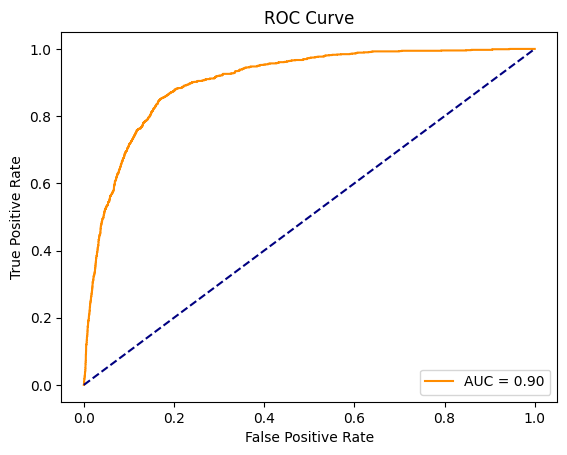

AUC Score: 0.9046075259992585


In [10]:
from sklearn.metrics import roc_curve, auc

# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("AUC Score:", roc_auc)